In [1]:
import matplotlib.pyplot as plt
import matplotlib
import scienceplots

import numpy as np
import pandas as pd

import os
import shutil

os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"
print("LaTeX found:", shutil.which('latex'))  # Should return a valid path

# Enable LaTeX
matplotlib.rcParams['text.usetex'] = True
# Set the style
plt.style.use(['science','ieee', 'std-colors'])
# plt.rcParams.update({'figure.dpi': '800'})
# plt.rcParams.update(plt.rcParamsDefault)


LaTeX found: /usr/bin/latex


In [2]:
import os
import json
import pandas as pd
from pathlib import Path

# Base directory
base_dir = Path('/Data/phi2FM_n_shot')

records = []

# Walk through modes, models, tasks
for mode in ['finetuning', 'lp']:
    mode_dir = base_dir / mode
    if not mode_dir.exists():
        continue
    for model_dir in mode_dir.iterdir():
        if not model_dir.is_dir():
            continue
        for task_dir in model_dir.iterdir():
            if not task_dir.is_dir():
                continue
            # nested task repetition
            nested = task_dir / task_dir.name
            if not nested.exists():
                continue
            for run_dir in nested.iterdir():
                if not run_dir.is_dir():
                    continue
                artifacts_path = run_dir / 'artifacts.json'
                if not artifacts_path.exists():
                    continue
                
                # load json first to get n_shots
                data = json.load(open(artifacts_path))
                # print(data)
                # Try to get n_shots from artifacts.json first
                n_shots = data.get("training_parameters", {}).get('n_shot')  # Changed from 'n_shots' to 'n_shot'

                
                # If not found in artifacts, parse from folder name as fallback
                if n_shots is None:
                    shots = run_dir.name.split('_')[-1]
                    try:
                        n_shots = int(shots)
                    except ValueError:
                        n_shots = None
                
                # Extract date from folder name (format: YYYYMMDD_...)
                # Parse date from the beginning of the folder name
                date_str = run_dir.name.split('_')[0]
                try:
                    # Convert YYYYMMDD to a comparable format
                    date_value = int(date_str) if date_str.isdigit() and len(date_str) == 8 else 0
                except (ValueError, IndexError):
                    date_value = 0
                metrics = data.get('test_metrics', {})
                if task_dir.name == "clouds":# and "f1_per_class" in metrics:
                    # print("OK")
                    f1_list = metrics["f1_per_class"]
                    if len(f1_list) >= 5:
                        clouds_f1 = float(np.mean([f1_list[1:3]]))
                    else:
                        clouds_f1 = None
                    f1_micro = clouds_f1
                    f1_macro = clouds_f1
                else:
                    f1_micro = metrics.get("f1_micro")
                    f1_macro = metrics.get("f1_macro")
                metrics = data.get('test_metrics', {})
                record = {
                    'mode': mode,
                    'model': model_dir.name,
                    'task': task_dir.name,
                    'n_shots': n_shots,
                    'date_value': date_value,
                    'precision_micro': metrics.get('precision_micro'),
                    'precision_macro': metrics.get('precision_macro'),
                    "recall_micro": metrics.get('recall_micro'),
                    "recall_macro": metrics.get("recall_macro"),
                    "f1_micro": f1_micro, #metrics.get("f1_micro"), 
                    "f1_macro": f1_macro, #metrics.get("f1_macro"),
                    'accuracy': metrics.get('acc')
                }
                # optionally include class-wise
                for i, p in enumerate(metrics.get('precision_per_class', [])):
                    record[f'precision_class_{i}'] = p
                records.append(record)

# Create DataFrame
df = pd.DataFrame(records)

# Keep only the latest run for each combination of mode, model, task, and n_shots
if not df.empty:
    # Sort by date_value and keep the latest for each group
    df = df.sort_values('date_value').groupby(['mode', 'model', 'task', 'n_shots']).last().reset_index()
    # Remove the date_value column as it's no longer needed
    #df = df.drop('date_value', axis=1)



In [3]:
print(df[df['task']=="clouds"])

           mode                 model    task  n_shots  date_value  \
5    finetuning         phi2_GeoAware  clouds       50    20250723   
6    finetuning         phi2_GeoAware  clouds      100    20250724   
7    finetuning         phi2_GeoAware  clouds      500    20250726   
8    finetuning         phi2_GeoAware  clouds     1000    20250729   
9    finetuning         phi2_GeoAware  clouds     5000    20250731   
..          ...                   ...     ...      ...         ...   
335          lp  phisatnet_downstream  clouds       50    20250811   
336          lp  phisatnet_downstream  clouds      100    20250812   
337          lp  phisatnet_downstream  clouds      500    20250813   
338          lp  phisatnet_downstream  clouds     1000    20250815   
339          lp  phisatnet_downstream  clouds     5000    20250816   

     precision_micro  precision_macro  recall_micro  recall_macro  f1_micro  \
5           0.160150         0.271551      0.160150      0.203206  0.239027   
6

In [4]:
print(df[(df['n_shots']==5000) & (df['mode']=='lp')][['model', 'task', 'f1_micro']])

                      model         task  f1_micro
178           phi2_GeoAware  burned_area  0.917420
183           phi2_GeoAware       clouds  0.598636
188           phi2_GeoAware         fire  0.794648
193           phi2_GeoAware  worldfloods  0.565344
198             phi2_SatMAE  burned_area  0.914654
203             phi2_SatMAE       clouds  0.627388
208             phi2_SatMAE         fire  0.750752
213             phi2_SatMAE  worldfloods  0.659051
218               phi2_caco  burned_area  0.827525
223               phi2_caco       clouds  0.377749
228               phi2_caco         fire  0.239627
233               phi2_caco  worldfloods  0.407734
238               phi2_dino  burned_area  0.884056
242               phi2_dino       clouds  0.427511
247               phi2_dino         fire  0.679796
252               phi2_dino  worldfloods  0.457764
257              phi2_gassl  burned_area  0.845616
262              phi2_gassl       clouds  0.620585
267              phi2_gassl    

<>:94: SyntaxWarning: invalid escape sequence '\P'
<>:95: SyntaxWarning: invalid escape sequence '\P'
<>:96: SyntaxWarning: invalid escape sequence '\P'
<>:180: SyntaxWarning: invalid escape sequence '\P'
<>:94: SyntaxWarning: invalid escape sequence '\P'
<>:95: SyntaxWarning: invalid escape sequence '\P'
<>:96: SyntaxWarning: invalid escape sequence '\P'
<>:180: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_2791805/262399943.py:94: SyntaxWarning: invalid escape sequence '\P'
  lw        = 3.0 if model == "$\Phi$satNet" else 1.6,
/tmp/ipykernel_2791805/262399943.py:95: SyntaxWarning: invalid escape sequence '\P'
  ms        = 6   if model == "$\Phi$satNet" else 4,
/tmp/ipykernel_2791805/262399943.py:96: SyntaxWarning: invalid escape sequence '\P'
  zorder    = 4   if model == "$\Phi$satNet" else 2,
/tmp/ipykernel_2791805/262399943.py:180: SyntaxWarning: invalid escape sequence '\P'
  if txt.get_text() == "$\Phi$satNet":


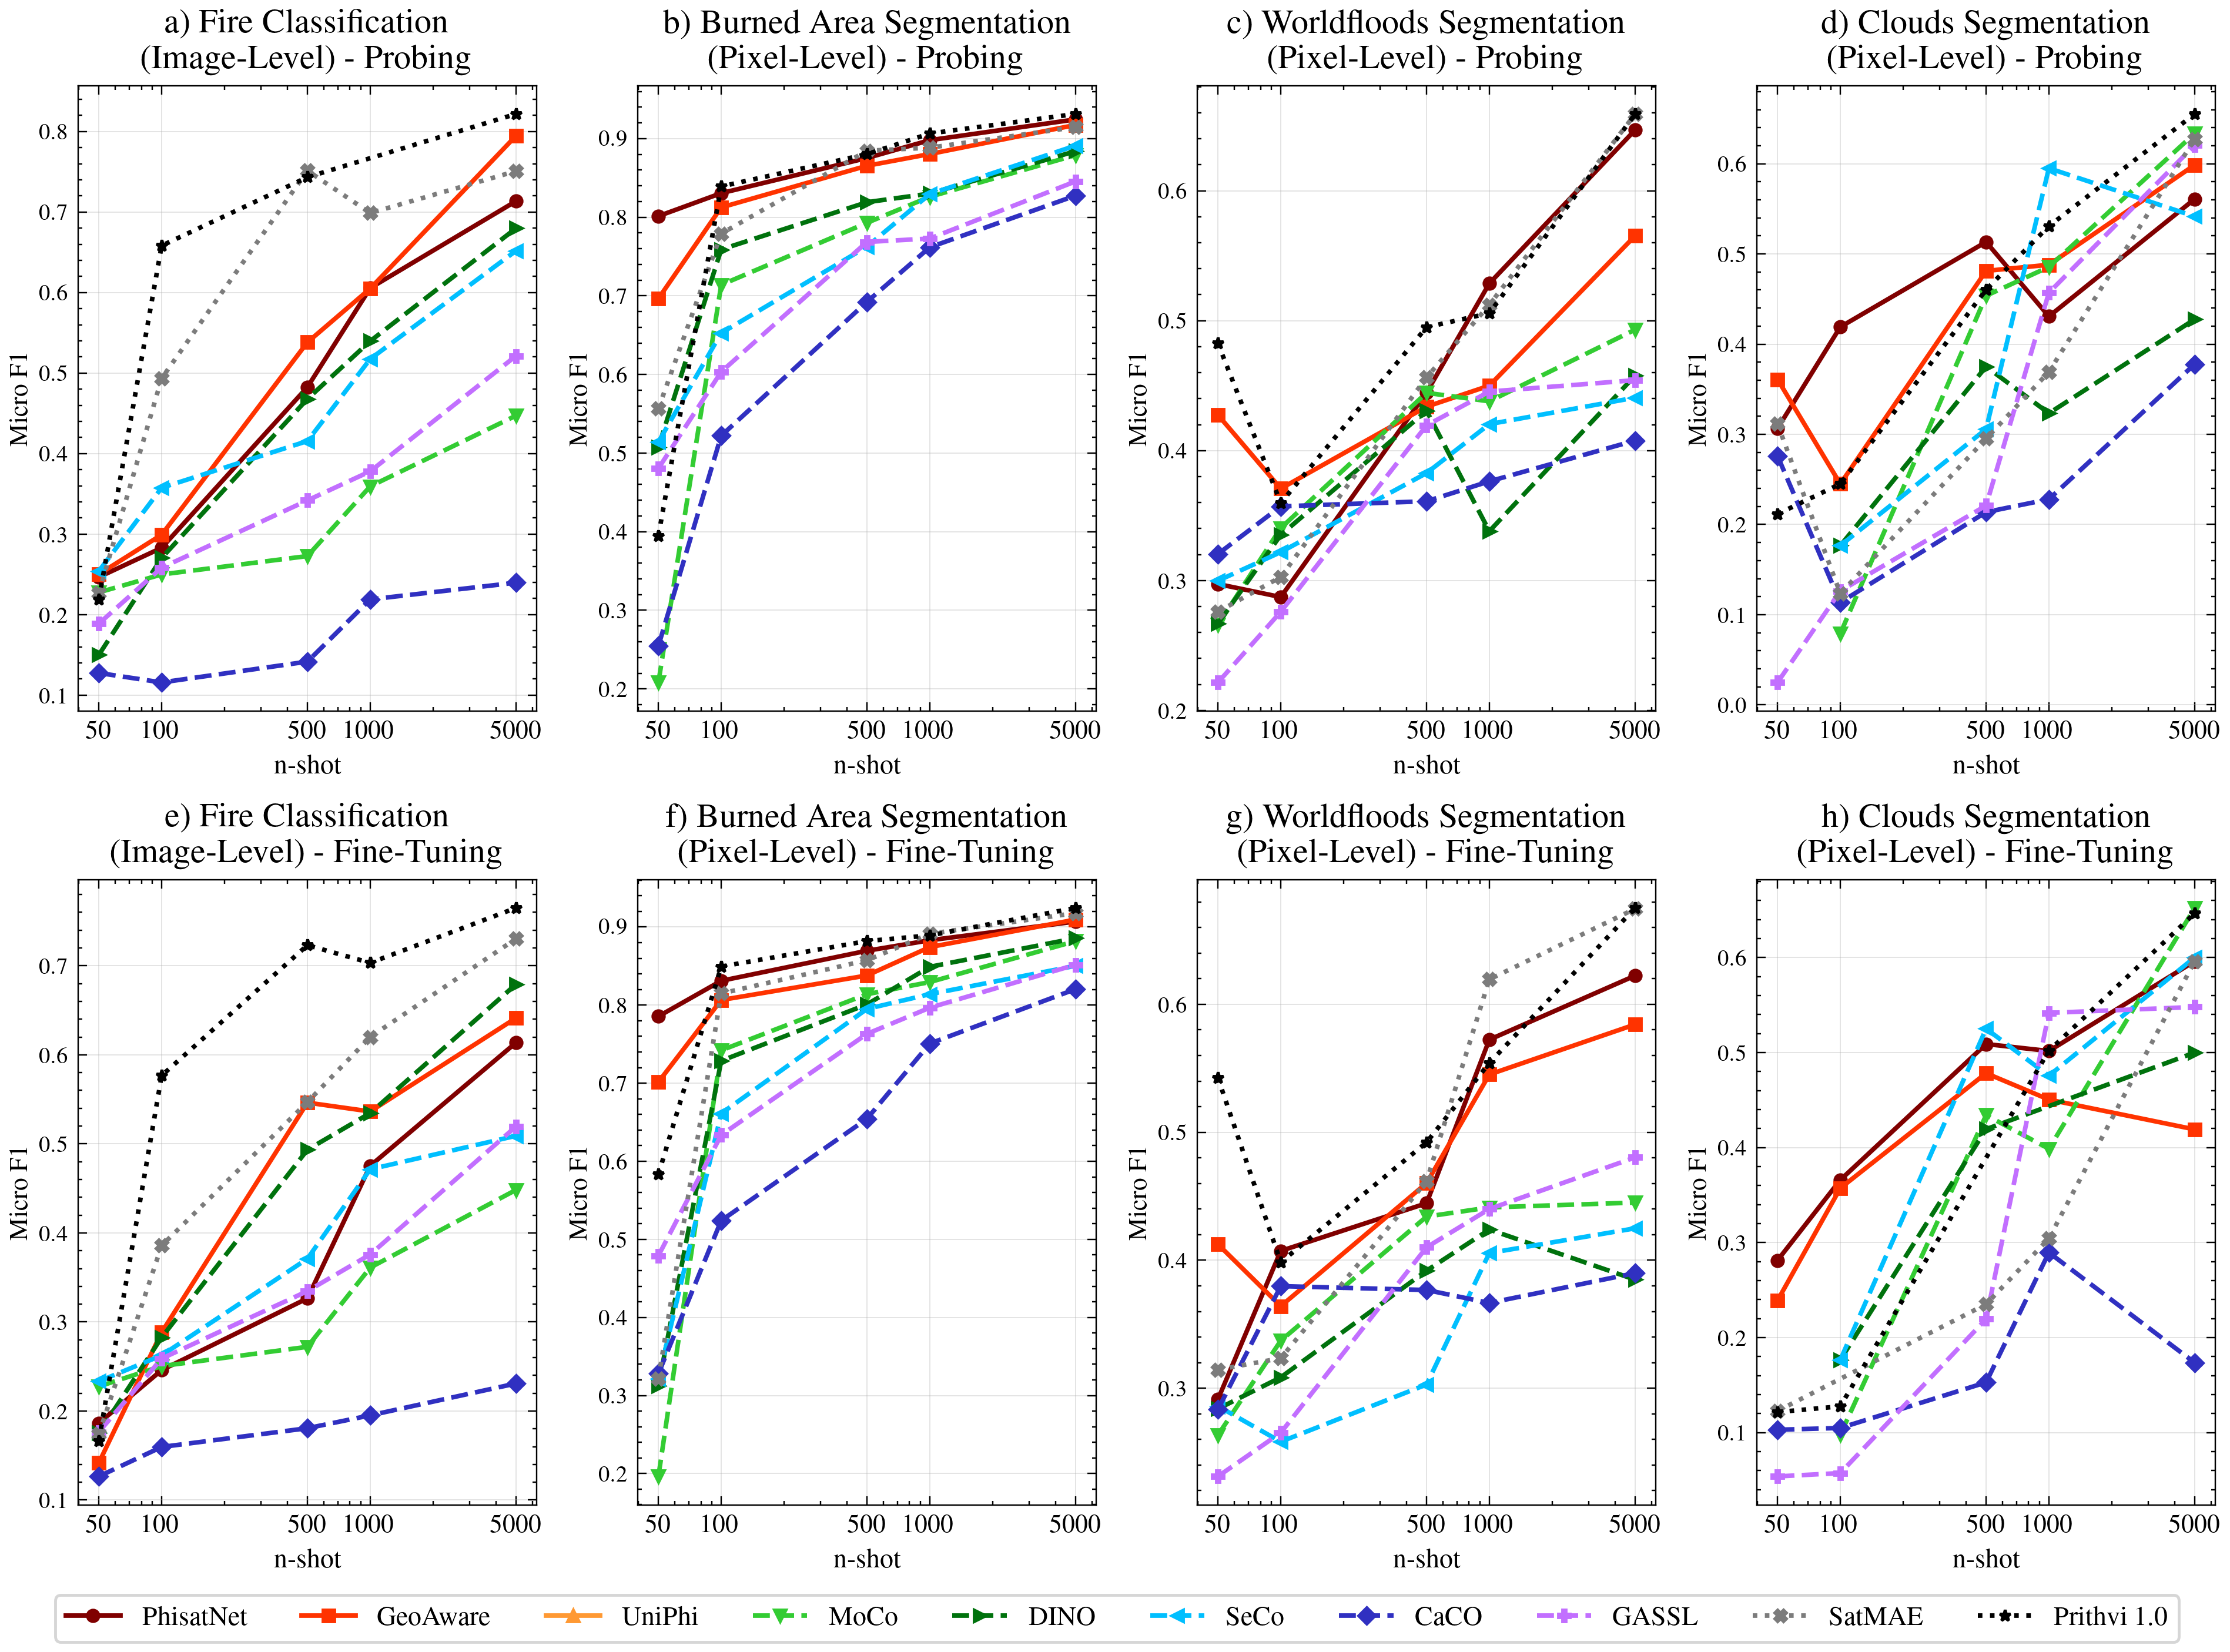

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import LogLocator, FormatStrFormatter, LogFormatterMathtext

# ─────────────────────────────────────────────────────────────────────────────
# 1.  Read & reshape the CSV
# ─────────────────────────────────────────────────────────────────────────────

FILENAME  = "data_plot_v2.csv"
FEW_SHOT  = [50, 100, 500, 1000, 5000]

#df = pd.read_csv(FILENAME, dtype={"model": str, "task": str})
#df.columns = (
#    ["model", "task", "ignore"]
#    + [f"lp_{s}" for s in FEW_SHOT]
#    + [f"f_{s}" for s in FEW_SHOT]
#)

model_names = {
    "CaCO": "phi2_caco",
    "DINO": "phi2_dino", 
    "GASSL": "phi2_gassl", 
    "GeoAware": "phi2_GeoAware", 
    "MoCo": "phi2_moco", 
    "PhisatNet": "phisatnet_downstream", 
    "Prithvi 1.0": "phi2_prithvi", 
    "SatMAE": "phi2_SatMAE", 
    "SeCo": "phi2_seasonal_contrast", 
    "UniPhi": "phi2_phileo_precursor", 
}

# data = {}
# for _, row in df.iterrows():
#     m, t = row["model"], row["task"]
#     if pd.notna(m) and pd.notna(t):
#         data.setdefault(m, {})[t] = {
#             "lp": [row[f"lp_{s}"] if pd.notna(row[f"lp_{s}"]) else None for s in FEW_SHOT],
#             "f":  [row[f"f_{s}"]  if pd.notna(row[f"f_{s}"])  else None for s in FEW_SHOT],
#         }

# ─────────────────────────────────────────────────────────────────────────────
# 2.  Task meta-data
# ─────────────────────────────────────────────────────────────────────────────
TASKS = [
    ("Fire Classification \n (Image-Level)",          "fire", "Micro F1"),
    ("Burned Area Segmentation \n (Pixel-Level)",    "burned_area", "Micro F1"),
    ("Worldfloods Segmentation \n (Pixel-Level)", "worldfloods", "Micro F1"),
    ("Clouds Segmentation \n (Pixel-Level)",    "clouds", "Micro F1"),
    #("Land Cover Segmentation \n (Pixel-Level)",     "lc",  "Micro F1"),
    #("Land Cover Classification \n (Image-Level)",   "lcc", "Micro F1"),
    #("Building Density Regression \n (Pixel-Level)", "blg", "MSE"),
    #("Road Density Regression \n (Pixel-Level)",     "rds", "MSE"),
]

GROUPS = {
    "U-Net":  ["PhisatNet", "GeoAware", "UniPhi"],
    "ResNet": ["MoCo", "DINO", "SeCo", "CaCO", "GASSL"],
    "ViT":    ["SatMAE", "Prithvi 1.0"],
}
MODEL_ORDER = [m for models in GROUPS.values() for m in models]

# ─────────────────────────────────────────────────────────────────────────────
# 3.  Explicit color map + markers + linestyles
# ─────────────────────────────────────────────────────────────────────────────
COLOR_MAP = {
    #"$\Phi$satNet":   "#800000",
    "PhisatNet":   "#800000",
    "GeoAware":    "#ff3300",
    "UniPhi":      "#ff9933",
    "MoCo":        "#33cc33",
    "DINO":        "#00720D",
    "SeCo":        "#00BFFF",
    "CaCO":        "#3030C1",
    "GASSL":       "#C26FFF",
    "Prithvi 1.0": "#000000",
    "SatMAE":      "#7C7C7C",
}

LINESTYLES = {"U-Net": "-", "ResNet": "--", "ViT": ":"}
MARKERS    = {
    "U-Net":  ["o", "s", "^"],
    "ResNet": ["v", ">", "<", "D", "P"],
    "ViT":    ["X", "*"],
}

model_styles = {}
for group, models in GROUPS.items():
    for idx, model in enumerate(models):
        model_styles[model] = dict(
            color     = COLOR_MAP[model],
            marker    = MARKERS[group][idx],
            linestyle = LINESTYLES[group],
            lw        = 3.0 if model == "$\Phi$satNet" else 1.6,
            ms        = 6   if model == "$\Phi$satNet" else 4,
            zorder    = 4   if model == "$\Phi$satNet" else 2,
        )

labels = [f"{chr(ord('a') + i)})" for i in range(8)]

# ─────────────────────────────────────────────────────────────────────────────
# 4.  Build figure
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(11, 8), dpi=350)

for col, (title, key, ylabel) in enumerate(TASKS):
    ax_lp, ax_ft = axes[0, col], axes[1, col]

    # draw curves in fixed order
    for model in MODEL_ORDER:
        # if key in data.get(model, {}):
        #     st = model_styles[model]
        #     lp_data = data[model][key]["lp"]
        #     ft_data = data[model][key]["f"]
        #     if key in {"blg", "rds"}:
        #         lp_data = [np.power(v, 1) if v is not None else None for v in lp_data]
        #         ft_data = [np.power(v, 1) if v is not None else None for v in ft_data]

        #     ax_lp.plot(FEW_SHOT, lp_data, label=model, **st)
        #     ax_ft.plot(FEW_SHOT, ft_data,  label=model, **st)
            sub_lp = df[(df["task"] == key) & (df["mode"] == "lp") & (df["model"] == model_names[model])]
            if not sub_lp.empty:
                # sort by n_shots
                sub_lp = sub_lp.sort_values("n_shots")
                xs = sub_lp["n_shots"].values
                ys = sub_lp["f1_micro"].values
                st = model_styles.get(model, {})
                ax_lp.plot(xs, ys, label=model, **st)

            # FT subplot
            sub_ft = df[(df["task"] == key) & (df["mode"] == "finetuning") & (df["model"] == model_names[model])]
            if not sub_ft.empty:
                sub_ft = sub_ft.sort_values("n_shots")
                xs = sub_ft["n_shots"].values
                ys = sub_ft["f1_micro"].values
                st = model_styles.get(model, {})
                ax_ft.plot(xs, ys, label=model, **st)
        

    # common cosmetics
    for ax in (ax_lp, ax_ft):
        ax.set_xscale("log")
        ax.set_xticks(FEW_SHOT)
        ax.set_xticklabels([str(s) for s in FEW_SHOT], fontsize=9)
        ax.set_xlabel("n-shot", fontsize=9.5)
        ax.margins(x=0.05)
        ax.grid(True, which="major", lw=0.4, alpha=0.35)

    # set y-label closer to axis
    ax_lp.set_ylabel(ylabel, labelpad=2, fontsize=9)
    ax_ft.set_ylabel(ylabel, labelpad=2, fontsize=9)

    ax_lp.set_title(f"{labels[col]} {title} - Probing", fontsize=12)
    ax_ft.set_title(f"{labels[4 + col]} {title} - Fine-Tuning", fontsize=12)

    # enhanced log–log for regression
    if key in {"blg", "rds"}:
        for ax in (ax_lp, ax_ft):
            ax.set_yscale("log")
            ax.yaxis.set_major_locator(LogLocator(base=10))
            ax.yaxis.set_minor_locator(LogLocator(base=10, subs=(2,5)))
            ax.yaxis.set_major_formatter(LogFormatterMathtext())
            ax.grid(True, which="minor", lw=0.25, alpha=0.2)

# ─────────────────────────────────────────────────────────────────────────────
# 5.  Unified legend
# ─────────────────────────────────────────────────────────────────────────────
handles = [mpl.lines.Line2D([], [], **model_styles[m], label=m)
           for m in MODEL_ORDER]
legend = fig.legend(
    handles=handles,
    labels=MODEL_ORDER,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.03),
    ncol=len(MODEL_ORDER),
    frameon=True,
    fontsize=9.5,
)
for txt in legend.get_texts():
    if txt.get_text() == "$\Phi$satNet":
        txt.set_weight("bold")

# ─────────────────────────────────────────────────────────────────────────────
# 6.  Save & show
# ─────────────────────────────────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.savefig("few_shot_experiments_grid.pdf", bbox_inches="tight")
plt.savefig("few_shot_experiments_grid.png", dpi=300, bbox_inches="tight")
plt.show()


In [2]:
import os
import json
import pandas as pd
from pathlib import Path

# Base directory
base_dir = Path('/Data/phisatnet_new_decoder')

records = []

# Walk through modes, models, tasks
for mode in ['finetuning', 'lp']:
    mode_dir = base_dir / mode
    if not mode_dir.exists():
        continue
    for model_dir in mode_dir.iterdir():
        if not model_dir.is_dir():
            continue
        for task_dir in model_dir.iterdir():
            if not task_dir.is_dir():
                continue
            # nested task repetition
            nested = task_dir / task_dir.name
            if not nested.exists():
                continue
            for run_dir in nested.iterdir():
                if not run_dir.is_dir():
                    continue
                artifacts_path = run_dir / 'artifacts.json'
                if not artifacts_path.exists():
                    continue
                
                # load json first to get n_shots
                data = json.load(open(artifacts_path))
                # print(data)
                # Try to get n_shots from artifacts.json first
                n_shots = data.get("training_parameters", {}).get('n_shot')  # Changed from 'n_shots' to 'n_shot'

                
                # If not found in artifacts, parse from folder name as fallback
                if n_shots is None:
                    shots = run_dir.name.split('_')[-1]
                    try:
                        n_shots = int(shots)
                    except ValueError:
                        n_shots = None
                
                # Extract date from folder name (format: YYYYMMDD_...)
                # Parse date from the beginning of the folder name
                date_str = run_dir.name.split('_')[0]
                try:
                    # Convert YYYYMMDD to a comparable format
                    date_value = int(date_str) if date_str.isdigit() and len(date_str) == 8 else 0
                except (ValueError, IndexError):
                    date_value = 0
                metrics = data.get('test_metrics', {})
                if task_dir.name == "clouds":# and "f1_per_class" in metrics:
                    # print("OK")
                    f1_list = metrics["f1_per_class"]
                    if len(f1_list) >= 5:
                        clouds_f1 = float(np.mean([f1_list[1:3]]))
                    else:
                        clouds_f1 = None
                    f1_micro = clouds_f1
                    f1_macro = clouds_f1
                else:
                    f1_micro = metrics.get("f1_micro")
                    f1_macro = metrics.get("f1_macro")
                metrics = data.get('test_metrics', {})
                record = {
                    'mode': mode,
                    'model': model_dir.name,
                    'task': task_dir.name,
                    'n_shots': n_shots,
                    'date_value': date_value,
                    'precision_micro': metrics.get('precision_micro'),
                    'precision_macro': metrics.get('precision_macro'),
                    "recall_micro": metrics.get('recall_micro'),
                    "recall_macro": metrics.get("recall_macro"),
                    "f1_micro": f1_micro, #metrics.get("f1_micro"), 
                    "f1_macro": f1_macro, #metrics.get("f1_macro"),
                    'accuracy': metrics.get('acc')
                }
                # optionally include class-wise
                for i, p in enumerate(metrics.get('precision_per_class', [])):
                    record[f'precision_class_{i}'] = p
                records.append(record)

# Create DataFrame
df = pd.DataFrame(records)

# Keep only the latest run for each combination of mode, model, task, and n_shots
if not df.empty:
    # Sort by date_value and keep the latest for each group
    df = df.sort_values('date_value').groupby(['mode', 'model', 'task', 'n_shots']).last().reset_index()
    # Remove the date_value column as it's no longer needed
    #df = df.drop('date_value', axis=1)

In [3]:
df

,mode,model,task,n_shots,date_value,precision_micro,precision_macro,recall_micro,recall_macro,f1_micro,f1_macro,accuracy,precision_class_0,precision_class_1,precision_class_2,precision_class_3
0,finetuning,phisatnet_downstream,burned_area,50,20250915,0.800587,0.803272,0.800587,0.805982,0.800587,0.804257,0.800587,0.796372,0.730296,0.820566,0.865853
1,finetuning,phisatnet_downstream,burned_area,100,20250915,0.814325,0.809663,0.814325,0.839595,0.814325,0.821384,0.814325,0.844409,0.785491,0.757103,0.851649
2,finetuning,phisatnet_downstream,burned_area,500,20250915,0.870877,0.864881,0.870877,0.900971,0.870877,0.879133,0.870877,0.913534,0.797564,0.819204,0.929222
3,finetuning,phisatnet_downstream,burned_area,1000,20250915,0.887412,0.879882,0.887412,0.915895,0.887412,0.894454,0.887412,0.933033,0.824114,0.837772,0.924608
4,finetuning,phisatnet_downstream,burned_area,5000,20250915,0.908763,0.901499,0.908763,0.928605,0.908763,0.913366,0.908763,0.942746,0.850121,0.889265,0.923864
5,lp,phisatnet_downstream,burned_area,100,20250915,0.844085,0.843844,0.844085,0.868094,0.844085,0.852765,0.844085,0.864348,0.770931,0.813766,0.926331
6,lp,phisatnet_downstream,burned_area,500,20250915,0.882804,0.876145,0.882804,0.910278,0.882804,0.890133,0.882804,0.922495,0.818601,0.839127,0.924358
7,lp,phisatnet_downstream,burned_area,1000,20250915,0.901946,0.895632,0.901946,0.926836,0.901946,0.908327,0.901946,0.942379,0.822113,0.868345,0.949691
8,lp,phisatnet_downstream,burned_area,5000,20250916,0.923797,0.916764,0.923797,0.943217,0.923797,0.928220,0.923797,0.959364,0.854096,0.906326,0.947269


In [2]:
import os
import json
import pandas as pd
from pathlib import Path

# Base directory
base_dir = Path('/Data/phisatnet_new_decoder_super_tiny/')

records = []

# Walk through modes, models, tasks
for mode in ['finetuning', 'lp']:
    mode_dir = base_dir / mode
    if not mode_dir.exists():
        continue
    for model_dir in mode_dir.iterdir():
        if not model_dir.is_dir():
            continue
        for task_dir in model_dir.iterdir():
            if not task_dir.is_dir():
                continue
            # nested task repetition
            nested = task_dir / task_dir.name
            if not nested.exists():
                continue
            for run_dir in nested.iterdir():
                if not run_dir.is_dir():
                    continue
                artifacts_path = run_dir / 'artifacts.json'
                if not artifacts_path.exists():
                    continue
                
                # load json first to get n_shots
                data = json.load(open(artifacts_path))
                # print(data)
                # Try to get n_shots from artifacts.json first
                n_shots = data.get("training_parameters", {}).get('n_shot')  # Changed from 'n_shots' to 'n_shot'

                
                # If not found in artifacts, parse from folder name as fallback
                if n_shots is None:
                    shots = run_dir.name.split('_')[-1]
                    try:
                        n_shots = int(shots)
                    except ValueError:
                        n_shots = None
                
                # Extract date from folder name (format: YYYYMMDD_...)
                # Parse date from the beginning of the folder name
                date_str = run_dir.name.split('_')[0]
                try:
                    # Convert YYYYMMDD to a comparable format
                    date_value = int(date_str) if date_str.isdigit() and len(date_str) == 8 else 0
                except (ValueError, IndexError):
                    date_value = 0
                metrics = data.get('test_metrics', {})
                if task_dir.name == "clouds":# and "f1_per_class" in metrics:
                    # print("OK")
                    f1_list = metrics["f1_per_class"]
                    if len(f1_list) >= 5:
                        clouds_f1 = float(np.mean([f1_list[1:3]]))
                    else:
                        clouds_f1 = None
                    f1_micro = clouds_f1
                    f1_macro = clouds_f1
                else:
                    f1_micro = metrics.get("f1_micro")
                    f1_macro = metrics.get("f1_macro")
                metrics = data.get('test_metrics', {})
                record = {
                    'mode': mode,
                    'model': model_dir.name,
                    'task': task_dir.name,
                    'n_shots': n_shots,
                    'date_value': date_value,
                    'precision_micro': metrics.get('precision_micro'),
                    'precision_macro': metrics.get('precision_macro'),
                    "recall_micro": metrics.get('recall_micro'),
                    "recall_macro": metrics.get("recall_macro"),
                    "f1_micro": f1_micro, #metrics.get("f1_micro"), 
                    "f1_macro": f1_macro, #metrics.get("f1_macro"),
                    'accuracy': metrics.get('acc')
                }
                # optionally include class-wise
                for i, p in enumerate(metrics.get('precision_per_class', [])):
                    record[f'precision_class_{i}'] = p
                records.append(record)

# Create DataFrame
df = pd.DataFrame(records)

# Keep only the latest run for each combination of mode, model, task, and n_shots
if not df.empty:
    # Sort by date_value and keep the latest for each group
    df = df.sort_values('date_value').groupby(['mode', 'model', 'task', 'n_shots']).last().reset_index()
    # Remove the date_value column as it's no longer needed
    #df = df.drop('date_value', axis=1)
df

,mode,model,task,n_shots,date_value,precision_micro,precision_macro,recall_micro,recall_macro,f1_micro,f1_macro,accuracy,precision_class_0,precision_class_1,precision_class_2,precision_class_3
0,finetuning,phisatnet_downstream,burned_area,50,20250917,0.801091,0.799752,0.801091,0.838664,0.801091,0.811126,0.801091,0.870443,0.664935,0.776630,0.887002
1,finetuning,phisatnet_downstream,burned_area,100,20250917,0.832914,0.832444,0.832914,0.859834,0.832914,0.841818,0.832914,0.863404,0.739751,0.810449,0.916173
2,finetuning,phisatnet_downstream,burned_area,500,20250917,0.880416,0.874265,0.880416,0.906780,0.880416,0.887684,0.880416,0.917270,0.810291,0.841521,0.927980
3,finetuning,phisatnet_downstream,burned_area,1000,20250917,0.897589,0.891707,0.897589,0.922451,0.897589,0.904195,0.897589,0.936169,0.824954,0.850493,0.955214
4,finetuning,phisatnet_downstream,burned_area,5000,20250917,0.916205,0.908658,0.916205,0.938393,0.916205,0.921259,0.916205,0.956459,0.846295,0.888123,0.943754
5,lp,phisatnet_downstream,burned_area,50,20250917,0.810448,0.808727,0.810448,0.850444,0.810448,0.820706,0.810448,0.883906,0.693387,0.746647,0.910969
6,lp,phisatnet_downstream,burned_area,100,20250917,0.845694,0.841587,0.845694,0.869674,0.845694,0.853608,0.845694,0.867421,0.802865,0.813035,0.883027
7,lp,phisatnet_downstream,burned_area,500,20250917,0.883924,0.877830,0.883924,0.909996,0.883924,0.891130,0.883924,0.920223,0.817166,0.842194,0.931738
8,lp,phisatnet_downstream,burned_area,1000,20250917,0.894213,0.886613,0.894213,0.923344,0.894213,0.901094,0.894213,0.944813,0.830408,0.831463,0.939767
9,lp,phisatnet_downstream,burned_area,5000,20250918,0.922900,0.917222,0.922900,0.939998,0.922900,0.927439,0.922900,0.948138,0.867884,0.906269,0.946597


In [1]:
import os
import json
import pandas as pd
from pathlib import Path

# Base directory
base_dir = Path('/Data/phisatnet_new_decoder_last/')

records = []

# Walk through modes, models, tasks
for mode in ['finetuning', 'lp']:
    mode_dir = base_dir / mode
    if not mode_dir.exists():
        continue
    for model_dir in mode_dir.iterdir():
        if not model_dir.is_dir():
            continue
        for task_dir in model_dir.iterdir():
            if not task_dir.is_dir():
                continue
            # nested task repetition
            nested = task_dir / task_dir.name
            if not nested.exists():
                continue
            for run_dir in nested.iterdir():
                if not run_dir.is_dir():
                    continue
                artifacts_path = run_dir / 'artifacts.json'
                if not artifacts_path.exists():
                    continue
                
                # load json first to get n_shots
                data = json.load(open(artifacts_path))
                # print(data)
                # Try to get n_shots from artifacts.json first
                n_shots = data.get("training_parameters", {}).get('n_shot')  # Changed from 'n_shots' to 'n_shot'

                
                # If not found in artifacts, parse from folder name as fallback
                if n_shots is None:
                    shots = run_dir.name.split('_')[-1]
                    try:
                        n_shots = int(shots)
                    except ValueError:
                        n_shots = None
                
                # Extract date from folder name (format: YYYYMMDD_...)
                # Parse date from the beginning of the folder name
                date_str = run_dir.name.split('_')[0]
                try:
                    # Convert YYYYMMDD to a comparable format
                    date_value = int(date_str) if date_str.isdigit() and len(date_str) == 8 else 0
                except (ValueError, IndexError):
                    date_value = 0
                metrics = data.get('test_metrics', {})
                if task_dir.name == "clouds":# and "f1_per_class" in metrics:
                    # print("OK")
                    f1_list = metrics["f1_per_class"]
                    if len(f1_list) >= 5:
                        clouds_f1 = float(np.mean([f1_list[1:3]]))
                    else:
                        clouds_f1 = None
                    f1_micro = clouds_f1
                    f1_macro = clouds_f1
                else:
                    f1_micro = metrics.get("f1_micro")
                    f1_macro = metrics.get("f1_macro")
                metrics = data.get('test_metrics', {})
                record = {
                    'mode': mode,
                    'model': model_dir.name,
                    'task': task_dir.name,
                    'n_shots': n_shots,
                    'date_value': date_value,
                    'precision_micro': metrics.get('precision_micro'),
                    'precision_macro': metrics.get('precision_macro'),
                    "recall_micro": metrics.get('recall_micro'),
                    "recall_macro": metrics.get("recall_macro"),
                    "f1_micro": f1_micro, #metrics.get("f1_micro"), 
                    "f1_macro": f1_macro, #metrics.get("f1_macro"),
                    'accuracy': metrics.get('acc')
                }
                # optionally include class-wise
                for i, p in enumerate(metrics.get('precision_per_class', [])):
                    record[f'precision_class_{i}'] = p
                records.append(record)

# Create DataFrame
df = pd.DataFrame(records)

# Keep only the latest run for each combination of mode, model, task, and n_shots
if not df.empty:
    # Sort by date_value and keep the latest for each group
    df = df.sort_values('date_value').groupby(['mode', 'model', 'task', 'n_shots']).last().reset_index()
    # Remove the date_value column as it's no longer needed
    #df = df.drop('date_value', axis=1)
df

,mode,model,task,n_shots,date_value,precision_micro,precision_macro,recall_micro,recall_macro,f1_micro,f1_macro,accuracy,precision_class_0,precision_class_1,precision_class_2,precision_class_3
0,lp,phisatnet_downstream,burned_area,5000,20250918,0.920662,0.913335,0.920662,0.940802,0.920662,0.925268,0.920662,0.957061,0.855523,0.914135,0.92662
